<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Clasificaci%C3%B3n_regresi%C3%B3n_logistica_bonomial_danos_al_coraz%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto de los datos

El conjunto de datos trata con información relacionada del sector salud, es información histórica de variables clínicas de pacientes que padecen daños al corazón.

Las variables independientes:

* *BMI*: Indice de masa corporal con valores entre *12.02* y *94.85*.
* *Smoking*: Si la persona es fumadora o no con valores categóritos de *‘Yes’* o *‘No’*.
* *AlcoholDrinking* : Si consume alcohol o no, con valores categóricos de *‘Yes’* o *‘No’*.
* *Stroke*: Si padece alguna anomalía cerebrovascular, apoplejia o algo similar, con valores categóricos de *‘Yes’* o *‘No’*.
* *PhysicalHealth* Estado físico en lo general con valores entre *0* y *30*.
* *MentalHealth*. Estado mental en lo general con valores entre *0* y *30*.
* *DiffWalking* . Que si se le dificulta caminar o tiene algún padecimiento al caminar, con valores categóritoc de *‘Yes’* o *‘No’*.
* *Sex*: Género de la persona, con valores de *‘Female’* y *‘Male’* para distinguir al género femenino y masculino respectivamente.
* *AgeCategory*: Una clasificación de la edad de la persona de entre *18* y *80* años. La primera categoría con un rango de edad entre *18-24*, a partir de *25* con rangos de *5* en *5* hasta la clase de *75-80* y una última categoría mayores de *80* años.
* *Race*. Raza u origen de la persona con valores categóricos de *‘American Indian/Alaskan Native’, ’Asian’,’Black’, ’Hispanic’, ’Other’ y’White’*.
* *Diabetic*. Si padece o ha padecido de diabetes en cuatro condiciones siendo *Yes* y *No*  *‘borderline diabetes Yes’ condición antes de detectarse diabetes tipo 2, y *‘Yes (during pregnancy)’* durante embarazo.
* *PhysicalActivity* que si realiza actividad física, con valores categóricos de *‘Yes’* o *‘No’*.
* *GenHealth*: Estado general de salud de la persona con valores categóricos de *‘Excellent’*, *‘Very good’*, *‘Good’*, *‘Fair’* y *‘Poor’* con significado en español de excelente, muy buena, buena, regular y pobre o deficiente.
* *SleepTime*: valor numérico de las horas de sueño u horas que duerme la persona con valores en un rango entre *1* y *24*.
* *Asthma*: si padece de asma o no, con valores categóricos de *Yes’* o *‘No’*.
* *KidneyDisease*: si tiene algún padecimiento en los riñones, con valores categóricos de *‘Yes’* o *‘No’*.
* *SkinCancer*: si padece algún tipo de cáncer de piel, con valores categóricos de *‘Yes’* o *‘No’*.

La variable de interés como dependiente o variable de salida es la de daño al corazón (*HeartDisease*), con valores categóricos de *‘Yes’* o *‘No’*.

El caso de estudio puede encontrarse en *google collab* en el elnace https://colab.research.google.com/drive/1UksxtO4wthQzbMJZ3CApB8I4cNNSwSIg?usp=sharing .


De igual forma, el caso de estudio se puede encontrar en el en la dirección *url* https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Clasificaci%C3%B3n_regresi%C3%B3n_logistica_bonomial_danos_al_coraz%C3%B3n.ipynb .

Los datos se pueden encontrar en el espacio del autor *github.com* https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/muestra10000_danios_al_corazon2026.csv. Los datos son una muestra de *10000* registros y *18* variables.

Las funciones se pueden encontrar y reutilizar desde el espacio *github.com* **PENDIENTE**



# Objetivo

Construir y evaluar modelos de regresión logística binaria para datos daños de corazón.

Para construir el modelo de regresión loística, los datos originales no se escalan ni se estandarizan, solo se transforman con variables *dummys*, con ello se construyen los modeos de regresión logística tanto con datos desbalanceados y aplicando técnicas de balanceo de datos como *undersamplig*, *ovesamplig*, *SMOTE* y ponderación.

Las particiones serán aleatoriamente *70%* para datos de entrenamiento y *30%* para datos de validación.

Se presenta y describe la matriz de confusión para todos los modelos de regresión logística construidos

La evaluación se hace con las métricas de exactitud, precisión sensibilidad, *F1 Scrore* y el estadístico *Kappa* que se extraen de la matriz de confusión.

Al final, se deberá interpretar los estadísticos de la evaluación de modelos creados e indicar y justificar el por qué un modelo tiene mejor rendimiento que otro en términos de calidad predictiva.

# Descripción


## Cargar librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LassoCV
# from sklearn.linear_model import RidgeCV
from sklearn.metrics import ( mean_squared_error,
    mean_absolute_error,  r2_score )

from scipy.stats import shapiro
from scipy.stats import kstest
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset
import statsmodels.api as sm

# Para validar posutalados
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor)
from statsmodels.stats.diagnostic import (het_breuschpagan,
    linear_reset)
from statsmodels.stats.stattools import ( durbin_watson)
from scipy.stats import ( shapiro)
from scipy.stats import shapiro
from scipy.stats import kstest
from scipy.stats import anderson
from sklearn.linear_model import (  LassoCV)
from sklearn.linear_model import (  RidgeCV)
from sklearn.preprocessing import (PolynomialFeatures)
from sklearn.svm import SVR # Para modelos SVR

# Para arboles de regresión y bosques aleatorios
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree

## Cargar funciones



In [2]:
# Funciones para implementar y evaluar modelos de regresión logística Python
# Se crearn modelos de Regresión Logística
# Se valida el postulado de colinealidad
#
# Rubén Pizarro Gurrola
# Junio 2026

#========================================================
# CARGAR DATOS
#========================================================

def f_cargar_datos(ruta_archivo):

    datos = pd.read_csv(ruta_archivo)

    return datos

#========================================================
# VISUALIZAR HEAD Y TAIL
#========================================================

def f_visualizar_head_tail_reducido(
        datos,
        n = 6
):

    #----------------------------------------------------
    # Total columnas
    #----------------------------------------------------

    total_columnas = datos.shape[1]

    #----------------------------------------------------
    # Primeras 4 columnas
    #----------------------------------------------------

    idx_prim = list(
        range(
            min(4, total_columnas)
        )
    )

    #----------------------------------------------------
    # Últimas 4 columnas
    #----------------------------------------------------

    idx_ult = list(
        range(
            max(total_columnas - 4, 0),
            total_columnas
        )
    )

    #----------------------------------------------------
    # Evitar duplicados
    #----------------------------------------------------

    idx_ult = [
        i for i in idx_ult
        if i not in idx_prim
    ]

    #----------------------------------------------------
    # Subconjuntos
    #----------------------------------------------------

    datos_prim = datos.iloc[:, idx_prim]

    datos_ult = datos.iloc[:, idx_ult]

    #----------------------------------------------------
    # HEAD
    #----------------------------------------------------

    head_prim = (
        datos_prim
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    head_ult = (
        datos_ult
        .head(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # TAIL
    #----------------------------------------------------

    tail_prim = (
        datos_prim
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    tail_ult = (
        datos_ult
        .tail(n)
        .astype(str)
        .reset_index(drop = True)
    )

    #----------------------------------------------------
    # Separadores
    #----------------------------------------------------

    sep_head = pd.DataFrame({
        "...": ["..."] * n
    })

    sep_tail = pd.DataFrame({
        "...": ["..."] * n
    })

    #----------------------------------------------------
    # Combinar HEAD
    #----------------------------------------------------

    head_comb = pd.concat(

        [
            head_prim,
            sep_head,
            head_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Combinar TAIL
    #----------------------------------------------------

    tail_comb = pd.concat(

        [
            tail_prim,
            sep_tail,
            tail_ult
        ],

        axis = 1
    )

    #----------------------------------------------------
    # Fila separadora
    #----------------------------------------------------

    fila_sep = pd.DataFrame(

        [["..."] * head_comb.shape[1]],

        columns = head_comb.columns
    )

    #----------------------------------------------------
    # Tabla final
    #----------------------------------------------------

    tabla = pd.concat(

        [
            head_comb,
            fila_sep,
            tail_comb
        ],

        ignore_index = True
    )

    return tabla

#========================================================
# DESCRIBIR DATOS
#========================================================

#========================================================
# FUNCIÓN
# f_describir_datos()
#========================================================

def f_describir_datos(datos):

    import pandas as pd

    #----------------------------------------------------
    # ESTRUCTURA
    #----------------------------------------------------

    estructura = datos.dtypes

    #----------------------------------------------------
    # VARIABLES NUMÉRICAS
    #----------------------------------------------------

    variables_numericas = datos.select_dtypes(
        include=["number"]
    )

    describe_numericas = None

    if variables_numericas.shape[1] > 0:

        describe_numericas = (
            variables_numericas
            .describe()
            .T
            .round(4)
        )

    #----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #----------------------------------------------------

    variables_categoricas = datos.select_dtypes(
        include=["object", "category"]
    )

    frecuencias = {}

    for variable in variables_categoricas.columns:

        tabla = pd.DataFrame({

            "Frecuencia":
                datos[variable]
                .value_counts(),

            "Porcentaje":
                round(
                    datos[variable]
                    .value_counts(normalize=True)
                    * 100,
                    2
                )

        })

        frecuencias[variable] = tabla

    #----------------------------------------------------
    # RESULTADO
    #----------------------------------------------------

    return {
        "describe": describe_numericas,
        "frecuencias": frecuencias,
        "structure": estructura
    }

#=========================================================
# FUNCIÓN
# f_frecuencias_clases()
#=========================================================

def f_frecuencias_clases(
        datos,
        ncols = 3,
        figsize = (18, 12),
        hspace = 0.60,
        wspace = 0.30):

    """
    Genera diagramas de barras para todas las variables
    categóricas (object, category y bool).

    Argumentos:
    ------------------------------------------------------
    datos    : DataFrame
    ncols    : Número de columnas del grid
    figsize  : Tamaño de la figura
    hspace   : Espacio vertical entre filas
    wspace   : Espacio horizontal entre columnas
    """

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    #-----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #-----------------------------------------------------

    variables = datos.select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    ).columns.tolist()

    if len(variables) == 0:

        print(
            "No existen variables categóricas en el conjunto de datos."
        )

        return

    #-----------------------------------------------------
    # GRID
    #-----------------------------------------------------

    nvars = len(variables)

    nrows = int(
        np.ceil(
            nvars / ncols
        )
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize = figsize
    )

    #-----------------------------------------------------
    # ASEGURAR VECTOR DE EJES
    #-----------------------------------------------------

    if nvars == 1:

        axes = np.array([axes])

    else:

        axes = np.array(axes).reshape(-1)

    #-----------------------------------------------------
    # GRÁFICOS
    #-----------------------------------------------------

    for i, variable in enumerate(variables):

        frecuencias = (
            datos[variable]
            .value_counts(dropna = False)
        )

        frecuencias.plot(
            kind = "bar",
            ax = axes[i]
        )

        #-------------------------------------------------
        # TÍTULO
        #-------------------------------------------------

        axes[i].set_title(
            variable,
            fontsize = 11,
            pad = 12
        )

        axes[i].set_xlabel("")

        axes[i].set_ylabel(
            "Frecuencia"
        )

        #-------------------------------------------------
        # ROTACIÓN ETIQUETAS
        #-------------------------------------------------

        axes[i].tick_params(
            axis = "x",
            rotation = 45,
            labelsize = 8
        )

        #-------------------------------------------------
        # ETIQUETAS SOBRE BARRAS
        #-------------------------------------------------

        for barra in axes[i].patches:

            altura = barra.get_height()

            axes[i].annotate(

                f"{int(altura):,}",

                (
                    barra.get_x() +
                    barra.get_width()/2,
                    altura
                ),

                ha = "center",

                va = "bottom",

                fontsize = 8

            )

    #-----------------------------------------------------
    # ELIMINAR EJES SOBRANTES
    #-----------------------------------------------------

    for j in range(
        len(variables),
        len(axes)
    ):

        fig.delaxes(
            axes[j]
        )

    #-----------------------------------------------------
    # ESPACIADO
    #-----------------------------------------------------

    plt.subplots_adjust(

        hspace = hspace,

        wspace = wspace

    )

    plt.tight_layout(
        pad = 2.5
    )

    plt.show()


def f_estandarizar_escalar(datos,
                           decimales = 4):

    datos_est = datos.copy()
    datos_esc = datos.copy()

    columnas_num = datos.select_dtypes(include = np.number).columns

    scaler_est = StandardScaler()

    scaler_minmax = MinMaxScaler()

    datos_est[columnas_num] = np.round(
        scaler_est.fit_transform(datos[columnas_num]),
        decimales
    )

    datos_esc[columnas_num] = np.round(
        scaler_minmax.fit_transform(datos[columnas_num]),
        decimales
    )

    return {
        "datos_estandarizados": datos_est,
        "datos_escalados": datos_esc
    }


#=========================================================
# FUNCIÓN
# f_convertir_dummys()
#=========================================================

def f_convertir_dummys(datos):

    """
    Convierte automáticamente todas las variables
    categóricas (object, category y bool)
    en variables dummy.

    Argumentos
    ----------
    datos : DataFrame

    Retorna
    -------
    DataFrame con variables dummy
    """

    import pandas as pd

    #-----------------------------------------------------
    # COPIA
    #-----------------------------------------------------

    datos_dummys = datos.copy()

    #-----------------------------------------------------
    # VARIABLES CATEGÓRICAS
    #-----------------------------------------------------

    variables_categoricas = (
        datos_dummys
        .select_dtypes(
            include=[
                "object",
                "category",
                "bool"
            ]
        )
        .columns
    )

    #-----------------------------------------------------
    # DUMMIES
    #-----------------------------------------------------

    datos_dummys = pd.get_dummies(

        datos_dummys,

        columns = variables_categoricas,

        drop_first = True,

        dtype = int

    )

    #-----------------------------------------------------
    # INFORMACIÓN
    #-----------------------------------------------------

    print()

    print("="*40)

    print(" CONVERSIÓN A VARIABLES DUMMY ")

    print("="*40)

    print(
        "Variables originales :",
        datos.shape[1]
    )

    print(
        "Variables finales    :",
        datos_dummys.shape[1]
    )

    print(
        "Observaciones        :",
        datos_dummys.shape[0]
    )

    print("="*40)

    return datos_dummys

def f_particionar_datos(datos,
                         proporcion_entrenamiento = 0.7):

    datos_entrenamiento, datos_validacion = train_test_split(
        datos,
        train_size = proporcion_entrenamiento,
        random_state = 2026
    )

    return {
        "datos_entrenamiento": datos_entrenamiento,
        "datos_validacion": datos_validacion
    }

#=========================================================
# FUNCIÓN
# f_crear_modelo_regresion_logistica()
#=========================================================

def f_crear_modelo_regresion_logistica(
        datos,
        variable_dependiente,
        tipo="binomial",
        balanceo="ninguno",
        semilla=123):

    #-----------------------------------------------------
    # LIBRERÍAS
    #-----------------------------------------------------

    import pandas as pd
    import numpy as np

    from sklearn.linear_model import LogisticRegression

    from sklearn.utils import resample

    #-----------------------------------------------------
    # VALIDACIONES
    #-----------------------------------------------------

    if variable_dependiente not in datos.columns:

        raise ValueError(
            f"La variable '{variable_dependiente}' no existe."
        )

    #-----------------------------------------------------
    # COPIA
    #-----------------------------------------------------

    np.random.seed(semilla)

    datos = datos.copy()

    datos_originales = datos.copy()

    #-----------------------------------------------------
    # VARIABLE DEPENDIENTE
    #-----------------------------------------------------

    y = datos[variable_dependiente]

    X = datos.drop(
        columns=[variable_dependiente]
    )

    #-----------------------------------------------------
    # FRECUENCIAS ORIGINALES
    #-----------------------------------------------------

    frecuencias_originales = (
        y
        .value_counts()
        .to_dict()
    )

    porcentajes_originales = (
        y
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    #-----------------------------------------------------
    # NÚMERO DE CLASES
    #-----------------------------------------------------

    n_clases = y.nunique()

    #-----------------------------------------------------
    # PONDERACIONES
    #-----------------------------------------------------

    class_weight = None

    #-----------------------------------------------------
    # BALANCEO
    #-----------------------------------------------------

    if balanceo.lower() == "undersampling":

        frecuencia_min = y.value_counts().min()

        datos_balanceados = []

        for clase in y.unique():

            temp = datos[
                datos[variable_dependiente] == clase
            ]

            temp = resample(
                temp,
                replace=False,
                n_samples=frecuencia_min,
                random_state=semilla
            )

            datos_balanceados.append(temp)

        datos = pd.concat(
            datos_balanceados,
            axis=0
        )

        datos = datos.sample(
            frac=1,
            random_state=semilla
        )

        y = datos[variable_dependiente]

        X = datos.drop(
            columns=[variable_dependiente]
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "oversampling":

        frecuencia_max = y.value_counts().max()

        datos_balanceados = []

        for clase in y.unique():

            temp = datos[
                datos[variable_dependiente] == clase
            ]

            temp = resample(
                temp,
                replace=True,
                n_samples=frecuencia_max,
                random_state=semilla
            )

            datos_balanceados.append(temp)

        datos = pd.concat(
            datos_balanceados,
            axis=0
        )

        datos = datos.sample(
            frac=1,
            random_state=semilla
        )

        y = datos[variable_dependiente]

        X = datos.drop(
            columns=[variable_dependiente]
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "smote":

        from imblearn.over_sampling import SMOTE

        smote = SMOTE(
            random_state=semilla
        )

        X, y = smote.fit_resample(
            X,
            y
        )

    #-----------------------------------------------------

    elif balanceo.lower() == "ponderacion":

        class_weight = "balanced"

    #-----------------------------------------------------

    elif balanceo.lower() == "ninguno":

        pass

    #-----------------------------------------------------

    else:

        raise ValueError(
            "balanceo debe ser: "
            "'ninguno', "
            "'undersampling', "
            "'oversampling', "
            "'SMOTE' o "
            "'ponderacion'"
        )

    #-----------------------------------------------------
    # FRECUENCIAS ENTRENAMIENTO
    #-----------------------------------------------------

    frecuencias_entrenamiento = (
        pd.Series(y)
        .value_counts()
        .to_dict()
    )

    porcentajes_entrenamiento = (
        pd.Series(y)
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .to_dict()
    )

    #-----------------------------------------------------
    # MODELO BINOMIAL
    #-----------------------------------------------------

    if tipo.lower() == "binomial":

        if n_clases != 2:

            raise ValueError(
                "La regresión logística binomial "
                "requiere exactamente 2 clases."
            )

        modelo = LogisticRegression(

            class_weight=class_weight,

            max_iter=5000,

            random_state=semilla

        )

    #-----------------------------------------------------
    # MODELO MULTINOMIAL
    #-----------------------------------------------------

    elif tipo.lower() == "multinomial":

        modelo = LogisticRegression(

            multi_class="multinomial",

            solver="lbfgs",

            class_weight=class_weight,

            max_iter=5000,

            random_state=semilla

        )

    #-----------------------------------------------------

    else:

        raise ValueError(
            "tipo debe ser "
            "'binomial' o "
            "'multinomial'"
        )

    #-----------------------------------------------------
    # AJUSTE
    #-----------------------------------------------------

    modelo.fit(X, y)

    #-----------------------------------------------------
    # METADATOS
    #-----------------------------------------------------

    modelo.variable_dependiente = variable_dependiente

    modelo.tipo_modelo = tipo

    modelo.balanceo = balanceo

    modelo.n_clases = n_clases

    modelo.frecuencias_originales = frecuencias_originales

    modelo.porcentajes_originales = porcentajes_originales

    modelo.frecuencias_entrenamiento = frecuencias_entrenamiento

    modelo.porcentajes_entrenamiento = porcentajes_entrenamiento

    #-----------------------------------------------------
    # RESUMEN
    #-----------------------------------------------------

    print()

    print("="*50)

    print(" REGRESIÓN LOGÍSTICA ")

    print("="*50)

    print("Tipo               :", tipo)

    print("Balanceo           :", balanceo)

    print("Variable objetivo  :", variable_dependiente)

    print("Número de clases   :", n_clases)

    print()

    print("Frecuencias originales:")

    print(frecuencias_originales)

    print()

    print("Frecuencias entrenamiento:")

    print(frecuencias_entrenamiento)

    print()

    print("Observaciones usadas:", len(y))

    print("="*50)

    return modelo

#=========================================================
# FUNCIÓN
# f_predicciones()
#=========================================================

def f_predicciones(
        modelo,
        datos_validacion,
        variable_dependiente):

    import pandas as pd
    import numpy as np

    #-----------------------------------------------------
    # VARIABLES INDEPENDIENTES
    #-----------------------------------------------------

    X = datos_validacion.drop(
        columns=[variable_dependiente]
    )

    #-----------------------------------------------------
    # CLASES PREDICHAS
    #-----------------------------------------------------

    pred = modelo.predict(X)

    #-----------------------------------------------------
    # PROBABILIDADES
    #-----------------------------------------------------

    prob = modelo.predict_proba(X)

    #-----------------------------------------------------
    # BINOMIAL
    #-----------------------------------------------------

    if len(modelo.classes_) == 2:

        probabilidad = prob[:,1]

    #-----------------------------------------------------
    # MULTINOMIAL
    #-----------------------------------------------------

    else:

        probabilidad = np.max(
            prob,
            axis=1
        )

    #-----------------------------------------------------
    # RESULTADO
    #-----------------------------------------------------

    resultado = pd.DataFrame({

        "Real":
            datos_validacion[
                variable_dependiente
            ].values,

        "Prediccion":
            pred,

        "Probabilidad":
            np.round(
                probabilidad,
                4
            )

    })

    resultado["Porcentual"] = (

        resultado["Probabilidad"] * 100

    ).round(2).astype(str) + " %"

    return resultado

#=========================================================
# FUNCIÓN
# f_matriz_confusion()
#=========================================================

def f_matriz_confusion(
        modelo,
        datos_validacion,
        variable_dependiente,
        clase_interes=None):

    import pandas as pd

    from sklearn.metrics import (
        confusion_matrix,
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        balanced_accuracy_score,
        cohen_kappa_score
    )

    #-----------------------------------------------------
    # DATOS
    #-----------------------------------------------------

    X = datos_validacion.drop(
        columns=[variable_dependiente]
    )

    y_real = datos_validacion[
        variable_dependiente
    ]

    y_pred = modelo.predict(X)

    #-----------------------------------------------------
    # MATRIZ
    #-----------------------------------------------------

    matriz = confusion_matrix(
        y_real,
        y_pred
    )

    tabla_mc = pd.DataFrame(

        matriz,

        index=[
            f"Real_{x}"
            for x in modelo.classes_
        ],

        columns=[
            f"Pred_{x}"
            for x in modelo.classes_
        ]

    )

    #-----------------------------------------------------
    # MÉTRICAS
    #-----------------------------------------------------

    accuracy = accuracy_score(
        y_real,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_real,
        y_pred
    )

    #-----------------------------------------------------
    # BINOMIAL
    #-----------------------------------------------------

    if len(modelo.classes_) == 2:

        if clase_interes is None:

            clase_interes = modelo.classes_[1]

        precision = precision_score(

            y_real,

            y_pred,

            pos_label=clase_interes

        )

        recall = recall_score(

            y_real,

            y_pred,

            pos_label=clase_interes

        )

        f1 = f1_score(

            y_real,

            y_pred,

            pos_label=clase_interes

        )

        balanced_accuracy = (

            balanced_accuracy_score(

                y_real,

                y_pred

            )

        )

    #-----------------------------------------------------
    # MULTINOMIAL
    #-----------------------------------------------------

    else:

        precision = precision_score(

            y_real,

            y_pred,

            average="weighted"

        )

        recall = recall_score(

            y_real,

            y_pred,

            average="weighted"

        )

        f1 = f1_score(

            y_real,

            y_pred,

            average="weighted"

        )

        balanced_accuracy = (

            balanced_accuracy_score(

                y_real,

                y_pred

            )

        )

    #-----------------------------------------------------
    # RESULTADOS
    #-----------------------------------------------------

    estadisticos = pd.DataFrame({

        "Accuracy":
            [round(accuracy,4)],

        "Kappa":
            [round(kappa,4)],

        "Precision":
            [round(precision,4)],

        "Recall":
            [round(recall,4)],

        "F1":
            [round(f1,4)],

        "Balanced_Accuracy":
            [round(
                balanced_accuracy,
                4
            )]

    })

    return {

        "matriz_confusion":
            tabla_mc,

        "estadisticos":
            estadisticos

    }

#=========================================================
# FUNCIÓN
# f_evaluacion()
#=========================================================

def f_evaluacion(
        modelos,
        datos_validacion,
        variable_dependiente,
        clase_interes=None,
        nombres_modelos=None):

    import pandas as pd

    #-----------------------------------------------------
    # CONVERTIR MODELO A LISTA
    #-----------------------------------------------------

    if not isinstance(modelos, list):

        modelos = [modelos]

    #-----------------------------------------------------
    # DATOS VALIDACIÓN
    #-----------------------------------------------------

    if not isinstance(datos_validacion, list):

        datos_validacion = (
            [datos_validacion]
            * len(modelos)
        )

    #-----------------------------------------------------
    # NOMBRES
    #-----------------------------------------------------

    if nombres_modelos is None:

        nombres_modelos = [

            f"Modelo {i+1}"

            for i in range(
                len(modelos)
            )

        ]

    #-----------------------------------------------------
    # RESULTADOS
    #-----------------------------------------------------

    resultados = []

    #-----------------------------------------------------
    # RECORRER MODELOS
    #-----------------------------------------------------

    for i in range(len(modelos)):

        modelo = modelos[i]

        datos_val = datos_validacion[i]

        nombre = nombres_modelos[i]

        #---------------------------------------------
        # MATRIZ DE CONFUSIÓN
        #---------------------------------------------

        resultado_mc = (

            f_matriz_confusion(

                modelo=modelo,

                datos_validacion=datos_val,

                variable_dependiente=
                    variable_dependiente,

                clase_interes=
                    clase_interes

            )

        )

        est = (
            resultado_mc[
                "estadisticos"
            ]
            .copy()
        )

        est.insert(
            0,
            "Modelo",
            nombre
        )

        #---------------------------------------------
        # BALANCEO
        #---------------------------------------------

        if hasattr(
            modelo,
            "balanceo"
        ):

            est.insert(

                1,

                "Balanceo",

                modelo.balanceo

            )

        resultados.append(est)

    #-----------------------------------------------------
    # UNIR
    #-----------------------------------------------------

    resultados = pd.concat(

        resultados,

        ignore_index=True

    )

    return resultados

In [3]:
# url = ""
# import requests

# exec(requests.get(url).text)

## Cargar datos


In [4]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/muestra10000_danios_al_corazon2026.csv"
datos = f_cargar_datos(url)

## Visualziar datos


In [5]:
f_visualizar_head_tail_reducido(datos)

,BMI,Smoking,AlcoholDrinking,Stroke,...,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,46.11,Yes,No,No,...,No,No,No,No
1,28.29,No,No,No,...,No,No,No,No
2,42.93,No,No,No,...,No,No,No,No
3,26.61,No,No,No,...,No,No,No,No
4,40.69,No,No,No,...,No,No,No,No
5,23.11,No,No,No,...,No,No,No,No
6,...,...,...,...,...,...,...,...,...
7,35.28,No,No,No,...,No,No,No,No
8,24.34,No,No,No,...,Yes,No,No,No
9,19.94,No,No,No,...,No,No,No,No


## Estadísticos descriptivos

Los estadísticos descriptivos se muestran con la función *f_describir_datos()* en modo consola.

Ejecutando la función *f_frecuencias_clases()* que despliega la visualización gráfica de la frecuencia de clsaes de los datos categóricos, y poniemndo atención especialmente a la variable dependiente *HeartDisease*, abajo a la derecha, se observa que hay un desbalance de clases, con el *91.04%* para valores no enfermos en relación al *8.96%* para pacientes enfermos.

Lo anterior presupone que las predicciones tienden a estimar muchos casos de pacientes no enfermos, por lo que hay que aplicar técnicas de balanceo de clases en la construccón de modelos de clasificación, como el de regresión logística binaraia de este caso de estudio.

In [6]:
f_describir_datos(datos)

{'describe':                   count     mean     std    min    25%    50%    75%    max
 BMI             10000.0  28.2919  6.3751  12.48  23.91  27.32  31.38  94.66
 PhysicalHealth  10000.0   3.5092  8.1639   0.00   0.00   0.00   2.00  30.00
 MentalHealth    10000.0   4.0102  8.1181   0.00   0.00   0.00   3.00  30.00
 SleepTime       10000.0   7.0881  1.4222   1.00   6.00   7.00   8.00  20.00,
 'frecuencias': {'Smoking':          Frecuencia  Porcentaje
  Smoking                        
  No             5860        58.6
  Yes            4140        41.4,
  'AlcoholDrinking':                  Frecuencia  Porcentaje
  AlcoholDrinking                        
  No                     9306       93.06
  Yes                     694        6.94,
  'Stroke':         Frecuencia  Porcentaje
  Stroke                        
  No            9617       96.17
  Yes            383        3.83,
  'DiffWalking':              Frecuencia  Porcentaje
  DiffWalking                        
  No             

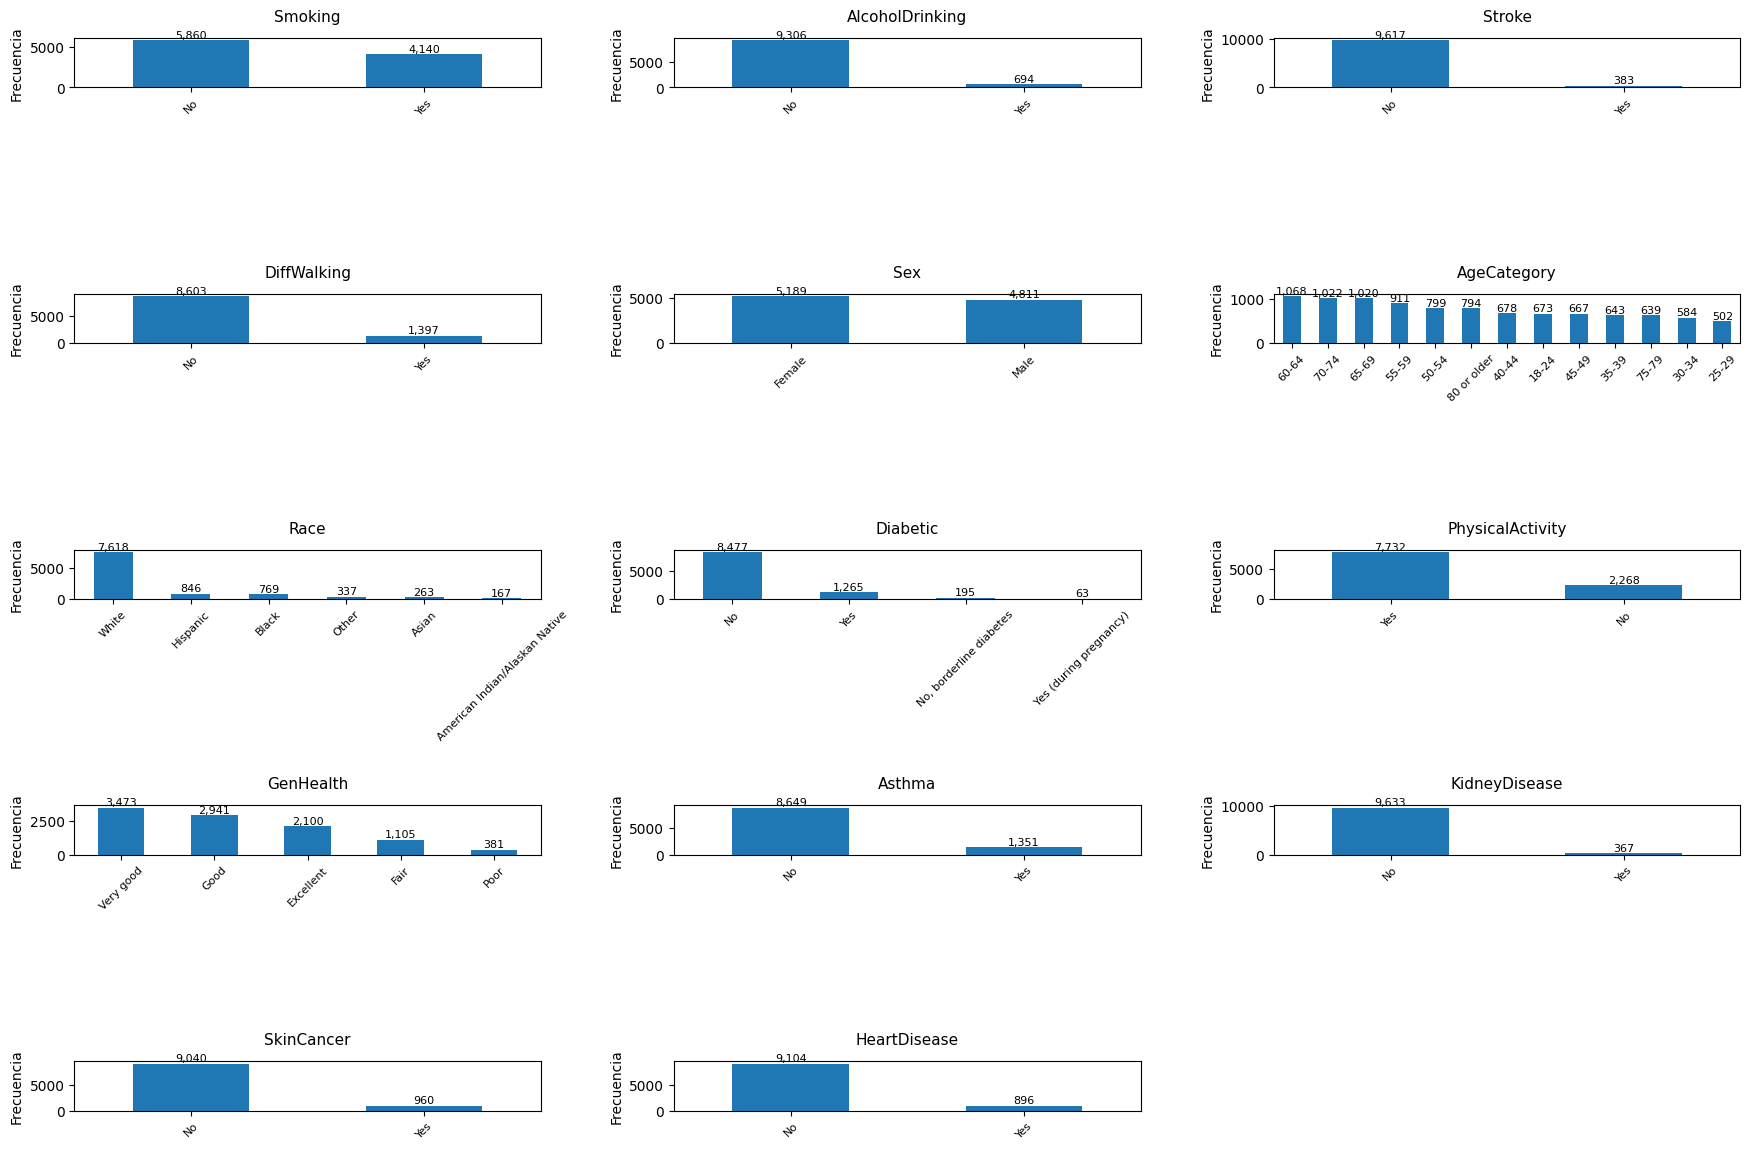

In [7]:
f_frecuencias_clases(datos)

## Transformar a variables dummys

Se transforman las variables categóricas con la función *f_convertir_dummys()* a variables *dummys*, ahora todas la variables categóricas tiene valores numéricos de acuerdo a los valores, sobre todo, la variable dependiente *HeartDisease*, tiene valores *0* para *'No'* enfermo y *1* para *'Yes'* o si enfermo.

Al construir variables *dummys* en el conjunto de datos, se modifican los nombres de variable de acuerdo a la mayor frecuencia de clase, la función devuelve los datos transforamados con los nombres cambiados de tal forma que ahora la variable dependietne se llama *HeartDisease_yes*.

Además, cuando hay clases multinomiales, se crean columnas por cada clase, lo que conlleva a tener ahora *38* columnas en el conjunto de datos transformados.

Esto decodificación, permite en *Python* construir los modelos de clasificación de manera mas amigable.

In [8]:
datos_transformados = f_convertir_dummys(datos)
f_visualizar_head_tail_reducido(datos_transformados)



 CONVERSIÓN A VARIABLES DUMMY 
Variables originales : 18
Variables finales    : 38
Observaciones        : 10000


,BMI,PhysicalHealth,MentalHealth,SleepTime,...,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes,HeartDisease_Yes
0,46.11,0,0,8,...,0,0,0,0
1,28.29,5,3,7,...,0,0,0,0
2,42.93,0,0,6,...,0,0,0,0
3,26.61,0,0,6,...,0,0,0,0
4,40.69,0,0,7,...,0,0,0,0
5,23.11,0,20,3,...,0,0,0,0
6,...,...,...,...,...,...,...,...,...
7,35.28,0,0,7,...,0,0,0,0
8,24.34,1,7,8,...,1,0,0,0
9,19.94,1,0,8,...,0,0,0,0


# Desarrollo


## Datos de entrenamiento y datos de validación

Con la función *f_particionar_datos()* se crean los conjuntos datos de entrenamiento con el *70%* y el *30%* para datos validación respectivamente.


Datos de entrenamiento:

In [9]:
particiones = f_particionar_datos(datos_transformados)
datos_entrenamiento = particiones["datos_entrenamiento"]
datos_validacion = particiones["datos_validacion"]
f_visualizar_head_tail_reducido(datos_entrenamiento)

,BMI,PhysicalHealth,MentalHealth,SleepTime,...,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes,HeartDisease_Yes
0,28.62,30,30,6,...,0,1,0,0
1,34.18,0,2,6,...,0,0,0,0
2,24.8,0,0,7,...,0,0,0,0
3,24.41,30,30,3,...,0,0,0,0
4,20.34,0,0,7,...,0,0,0,0
5,22.67,2,1,9,...,0,0,0,0
6,...,...,...,...,...,...,...,...,...
7,25.11,0,0,7,...,1,0,0,0
8,24.18,1,0,6,...,0,0,0,0
9,19.37,0,0,7,...,0,0,0,0


Datos de validación:

In [10]:
f_visualizar_head_tail_reducido(datos_validacion)

,BMI,PhysicalHealth,MentalHealth,SleepTime,...,Asthma_Yes,KidneyDisease_Yes,SkinCancer_Yes,HeartDisease_Yes
0,29.35,2,20,8,...,0,0,0,0
1,26.58,1,0,6,...,0,0,0,0
2,24.37,30,0,8,...,0,0,0,0
3,28.84,5,1,8,...,1,0,0,0
4,19.77,0,0,7,...,0,0,0,0
5,20.25,0,0,9,...,0,0,0,0
6,...,...,...,...,...,...,...,...,...
7,30.38,0,0,8,...,0,0,0,1
8,26.09,0,3,7,...,0,0,0,0
9,25.56,0,1,8,...,0,0,0,0


## Modelo regresión logística binomial

Se crea el modelo de regresión logística binomial (*RLB*) con los datos de entrenamiento ejecutando la función *f_crear_modelo_RLB()*, a quien se le indica el nombre de la variable dependiente que con la transformación a variables *dummys* ahora se llama *HeartDisease_Yes*.






In [11]:
modelo_RLB = f_crear_modelo_regresion_logistica(
    datos = datos_entrenamiento,
    variable_dependiente = "HeartDisease_Yes",
    tipo="binomial",
)



 REGRESIÓN LOGÍSTICA 
Tipo               : binomial
Balanceo           : ninguno
Variable objetivo  : HeartDisease_Yes
Número de clases   : 2

Frecuencias originales:
{0: 6397, 1: 603}

Frecuencias entrenamiento:
{0: 6397, 1: 603}

Observaciones usadas: 7000


### Predicciones de RLB

Con el modelo *modelo_RLB* se hacen predicciones usando los datos de validación con la función *f_predicciones()*.

Las prediccones incluyen el valor real, el valor de predicción y la probabilidad de que se de ese valor.

Lo anterior permite construir la matriz de confusión para extraer los estadísticos que sirven para evaluar la calidad predictiva del modelo.



In [12]:
predicciones_RLB = f_predicciones(
    modelo_RLB,
    datos_validacion,
    "HeartDisease_Yes"
)
predicciones_RLB

,Real,Prediccion,Probabilidad,Porcentual
0,0,0,0.0594,5.94 %
1,0,0,0.0451,4.51 %
2,0,0,0.0078,0.78 %
3,0,0,0.0390,3.9 %
4,0,0,0.0468,4.68 %
...,...,...,...,...
2995,0,0,0.0164,1.64 %
2996,0,0,0.0065,0.65 %
2997,0,0,0.3489,34.89 %
2998,0,0,0.2533,25.33 %


### Matriz de confusión

Con la función *f_matriz_confusion()* aes crea la matriz de confusión, la salida en modlo consola; se observa que el valor de exactitud predictiva del modelo está alrededor del *90%* sin embargo,  estadísticos como *Kappa* con valor de *0.1234*, de sensibilidad o *Recall* de *0.0853* e inclusive de *F1-Score* de *0.1471* hacen dudar de la eficiencia del modelo.

Lo anterior se debe a que se construyó el modelo con datos desbalanceados, lo que permite y da lugar para aplacar técnicas de balanceo de datos.




In [13]:
f_matriz_confusion(
    modelo_RLB,
    datos_validacion,
    "HeartDisease_Yes"
)

{'matriz_confusion':         Pred_0  Pred_1
 Real_0    2685      22
 Real_1     268      25,
 'estadisticos':    Accuracy   Kappa  Precision  Recall      F1  Balanced_Accuracy
 0    0.9033  0.1234     0.5319  0.0853  0.1471             0.5386}

## Balance de clase

### Undersamplig

In [14]:
modelo_RLB_US = f_crear_modelo_regresion_logistica(
        datos = datos_entrenamiento,
        variable_dependiente = "HeartDisease_Yes",
        tipo="binomial",
        balanceo="undersampling",
        semilla=2026)





 REGRESIÓN LOGÍSTICA 
Tipo               : binomial
Balanceo           : undersampling
Variable objetivo  : HeartDisease_Yes
Número de clases   : 2

Frecuencias originales:
{0: 6397, 1: 603}

Frecuencias entrenamiento:
{0: 603, 1: 603}

Observaciones usadas: 1206


### Oversampling


In [15]:
modelo_RLB_OS = f_crear_modelo_regresion_logistica(
        datos = datos_entrenamiento,
        variable_dependiente = "HeartDisease_Yes",
        tipo="binomial",
        balanceo="oversampling",
        semilla=2026)


 REGRESIÓN LOGÍSTICA 
Tipo               : binomial
Balanceo           : oversampling
Variable objetivo  : HeartDisease_Yes
Número de clases   : 2

Frecuencias originales:
{0: 6397, 1: 603}

Frecuencias entrenamiento:
{1: 6397, 0: 6397}

Observaciones usadas: 12794


### SMOTE


In [16]:
modelo_RLB_SMOTE = f_crear_modelo_regresion_logistica(
        datos = datos_entrenamiento,
        variable_dependiente = "HeartDisease_Yes",
        tipo="binomial",
        balanceo="SMOTE",
        semilla=2026)


 REGRESIÓN LOGÍSTICA 
Tipo               : binomial
Balanceo           : SMOTE
Variable objetivo  : HeartDisease_Yes
Número de clases   : 2

Frecuencias originales:
{0: 6397, 1: 603}

Frecuencias entrenamiento:
{0: 6397, 1: 6397}

Observaciones usadas: 12794


### Ponderación


In [17]:
modelo_RLB_PONDERA = f_crear_modelo_regresion_logistica(
        datos = datos_entrenamiento,
        variable_dependiente = "HeartDisease_Yes",
        tipo="binomial",
        balanceo="ponderacion",
        semilla=2026)


 REGRESIÓN LOGÍSTICA 
Tipo               : binomial
Balanceo           : ponderacion
Variable objetivo  : HeartDisease_Yes
Número de clases   : 2

Frecuencias originales:
{0: 6397, 1: 603}

Frecuencias entrenamiento:
{0: 6397, 1: 603}

Observaciones usadas: 7000


## Evaluación de modelos

Con los modelos creados, se hace la evaluación de modelos usando la función f_evaluacuón con los argumentos de cada modelo.

Los resultados en modo consola indican que habiendo aplicado técnicas de balanceo de clases, disminuye el estadístico de *accuracy* pero aumentan los estadísticos como sensibilidad, *Kappa*, entre otros, de tal manera que estos modelos que aplican técnicas de balanceo ofrecen mejor calidad predicitva tanto para pacientes enfermos como no enfermos.



In [18]:
evaluacion = f_evaluacion(

    modelos=[modelo_RLB,
        modelo_RLB_US,
        modelo_RLB_OS,
        modelo_RLB_SMOTE,
        modelo_RLB_PONDERA],

    datos_validacion=[datos_validacion,
        datos_validacion,
        datos_validacion,
        datos_validacion,
        datos_validacion],

    variable_dependiente=
        "HeartDisease_Yes",

    clase_interes=
        1,

    nombres_modelos=["Original",
        "Undersampling",
        "Oversampling",
        "SMOTE",
        "Ponderado"]
)

evaluacion

,Modelo,Balanceo,Accuracy,Kappa,Precision,Recall,F1,Balanced_Accuracy
0,Original,ninguno,0.9033,0.1234,0.5319,0.0853,0.1471,0.5386
1,Undersampling,undersampling,0.7440,0.2444,0.2358,0.7235,0.3557,0.7349
2,Oversampling,oversampling,0.7503,0.2590,0.2444,0.7440,0.3679,0.7475
3,SMOTE,SMOTE,0.7927,0.1326,0.1879,0.3379,0.2415,0.5899
4,Ponderado,ponderacion,0.7543,0.2697,0.2506,0.7611,0.3770,0.7573


# Interpretación del caso de estudio

El caso de estudio cumple con el objetivo planteado al inicio del mismo.

Se construyeron modelos de clasificación utilizando el algoritmo de regresión logística binaria.

Los datos fueron particionados *70%* para datos de entrenamiento y *30%* para datos de validación.

Las variables categórcias incluyendo la variable dependiente, fueron transformadas a variables *dummys*, lo que permitió utilizar las funciones para crear modelos de regresión logística binaria con datos desbalacenados.

Posteriormente se crearon modelos alternativos pero con datos balanceados aplicando técnicas como *undersampling*, *oversampling*, *SMOTE* y poderación de la variable clase.

Al final se tiene una evaluacón de los distintos modelos llegando a la conclusión de que el mejor modelo aplicado es el modelo de regresión logística binaria con la técnica de *SMOTE* para estos datos desbalanceados.

Los resultados que ofrece la evaluaciónb demodelos son similares a los que ofrece R.

Para el lector este caso de estudio sirve como una guia para aplciarlo con sus propios datos y reutilziar las funcione sy estrufyira aquí presentada.
